# ELOM OLUCHI LUCY
# Track: Data Analytics (Oasis Infobyte SIP)
# Task: Level 2 - House Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid")
df = fetch_california_housing(as_frame=True).frame
df.to_csv("california_housing.csv", index=False)

print(df.shape, "| Missing:", df.isna().sum().sum())
df.head()

(20640, 9) | Missing: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


               count     mean      std     min     25%      50%      75%  \
MedInc       20640.0     3.87     1.90    0.50    2.56     3.53     4.74   
HouseAge     20640.0    28.64    12.59    1.00   18.00    29.00    37.00   
AveRooms     20640.0     5.43     2.47    0.85    4.44     5.23     6.05   
AveBedrms    20640.0     1.10     0.47    0.33    1.01     1.05     1.10   
Population   20640.0  1425.48  1132.46    3.00  787.00  1166.00  1725.00   
AveOccup     20640.0     3.07    10.39    0.69    2.43     2.82     3.28   
Latitude     20640.0    35.63     2.14   32.54   33.93    34.26    37.71   
Longitude    20640.0  -119.57     2.00 -124.35 -121.80  -118.49  -118.01   
MedHouseVal  20640.0     2.07     1.15    0.15    1.20     1.80     2.65   

                  max  
MedInc          15.00  
HouseAge        52.00  
AveRooms       141.91  
AveBedrms       34.07  
Population   35682.00  
AveOccup      1243.33  
Latitude        41.95  
Longitude     -114.31  
MedHouseVal      5.00  

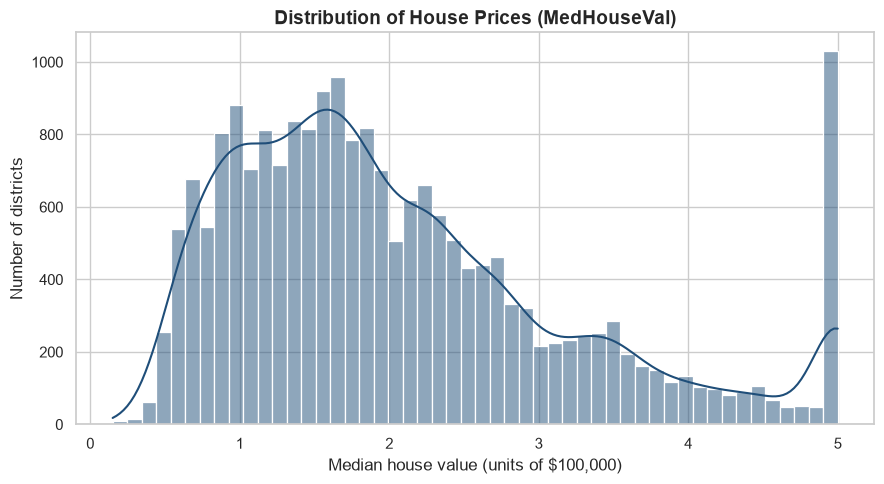

In [2]:
print(df.describe().round(2).T)

plt.figure(figsize=(9, 5))
sns.histplot(df["MedHouseVal"], bins=50, kde=True, color="#1f4e79")
plt.title("Distribution of House Prices (MedHouseVal)", fontsize=14, fontweight="bold")
plt.xlabel("Median house value (units of $100,000)")
plt.ylabel("Number of districts")
plt.tight_layout()
plt.show()

MedHouseVal    1.00
MedInc         0.69
AveRooms       0.15
HouseAge       0.11
Population    -0.02
AveOccup      -0.02
AveBedrms     -0.05
Longitude     -0.05
Latitude      -0.14
Name: MedHouseVal, dtype: float64


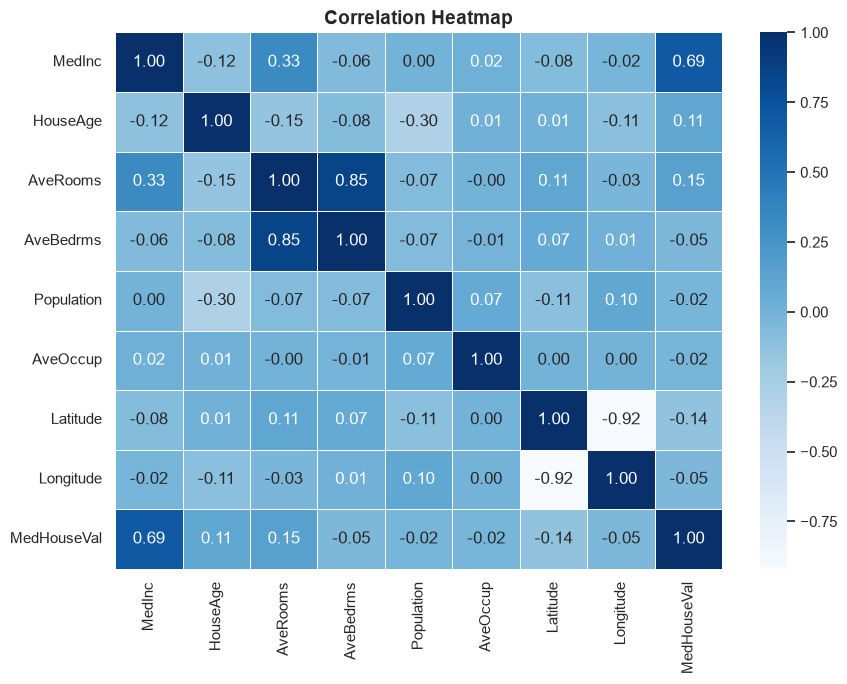

In [3]:
corr = df.corr().round(2)
print(corr["MedHouseVal"].sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Selection

All 8 features were kept as predictors. The reasoning:
- *MedInc* (median income) is the strongest predictor, with a correlation of 0.69 with price.
- *Latitude and Longitude* are also strongly linked to each other (-0.92), so they overlap in what they tell the model, and their individual coefficients should be read together.
- *AveRooms and AveBedrms* are strongly linked to each other (0.85), so they overlap. Both were kept for simplicity, and the model's coefficients for them should be read with care.
- *HouseAge, Population and AveOccup* have weak links with price, but they cost nothing to keep and Linear Regression can handle them

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

Training rows: 16512 | Test rows: 4128
MSE : 0.5559
RMSE: 0.7456
R2  : 0.5758


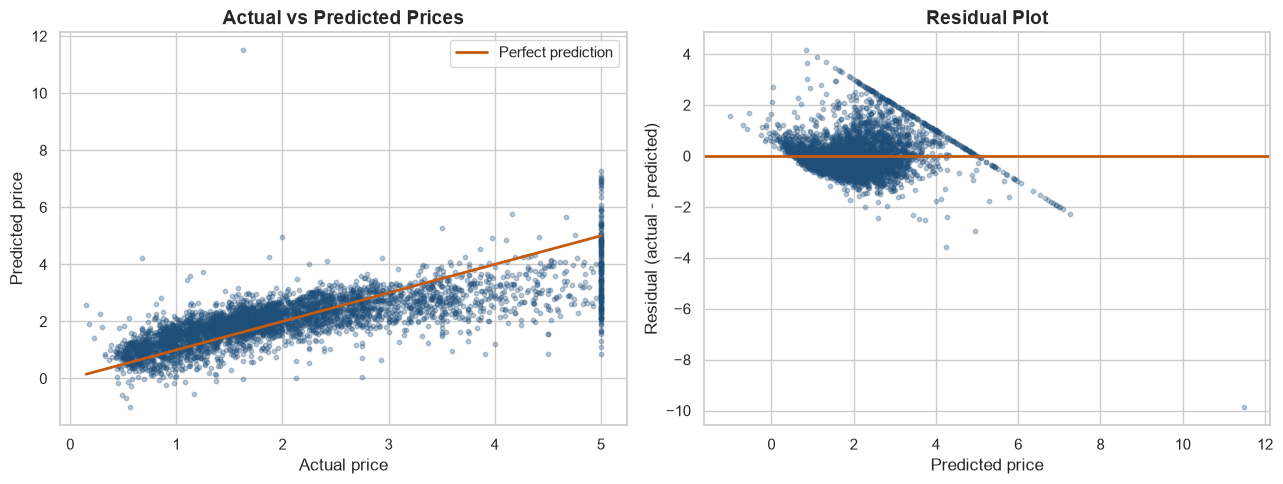

In [5]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(y_test, y_pred, alpha=0.3, color="#1f4e79", s=10)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
           color="#c55a11", linewidth=2, label="Perfect prediction")
ax[0].set_title("Actual vs Predicted Prices", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Actual price")
ax[0].set_ylabel("Predicted price")
ax[0].legend()

ax[1].scatter(y_pred, residuals, alpha=0.3, color="#1f4e79", s=10)
ax[1].axhline(0, color="#c55a11", linewidth=2)
ax[1].set_title("Residual Plot", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Predicted price")
ax[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

AveBedrms     0.7831
MedInc        0.4487
HouseAge      0.0097
Population   -0.0000
AveOccup     -0.0035
AveRooms     -0.1233
Latitude     -0.4198
Longitude    -0.4337
dtype: float64
Intercept: -37.0233


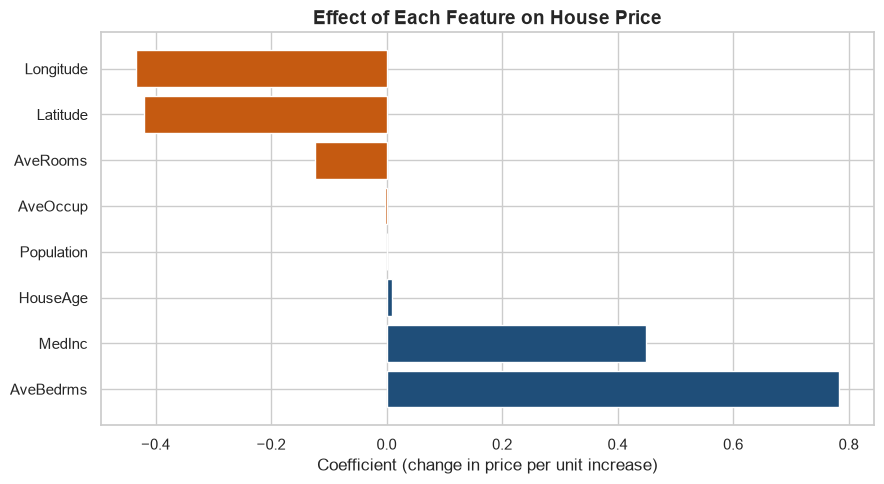

In [6]:
coef = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False).round(4)
print(coef)
print("Intercept:", round(model.intercept_, 4))

plt.figure(figsize=(9, 5))
colors = ["#1f4e79" if v > 0 else "#c55a11" for v in coef.values]
plt.barh(coef.index, coef.values, color=colors)
plt.title("Effect of Each Feature on House Price", fontsize=14, fontweight="bold")
plt.xlabel("Coefficient (change in price per unit increase)")
plt.tight_layout()
plt.show()

## Observations and Conclusion

*Data:* 20,640 districts and 8 features, with no missing values. The dataset has no category columns, so one-hot encoding was not needed.

*Target:* house prices (MedHouseVal, in units of 100,000) are skewed to the right and capped at 5.0, because prices above $500,000 were recorded as 5.0.

*Correlation:* median income (MedInc) has by far the strongest link to price (about 0.69). The other features have weak links.

*Model:* Linear Regression, trained on 80% of the data (16,512 districts) and tested on 20% (4,128 districts).

| Metric | Result |
|---|---|
| MSE | 0.5559|
| RMSE | 0.7456 |
| R-squared | 0.5758 |

*Actual vs predicted:* the model follows the general trend, but it predicts too low for expensive districts, and it cannot handle the cap at 5.0 (the vertical line of dots).

*Residuals:* most errors are close to zero, but the slanted line of dots comes from the price cap, which shows that a straight-line model misses some patterns.

*Coefficients:* the biggest positive effect comes from AveBedrms (0.78), followed by MedInc (0.45). The biggest negative effects come from Longitude (-0.43) and Latitude (-0.42). AveRooms and AveBedrms are strongly linked to each other (correlation 0.85), which is likely why AveRooms has a negative coefficient (-0.12) even though its direct link to price is positive (0.15). The features are measured in different units, so the coefficients should be read with care and not treated as a ranking of importance.

*Conclusion:* the model explains about 57.6 percent of the variation in prices. That is a reasonable start for a simple model. To improve it, try regularised models (Ridge or Lasso) or non-linear models such as Random Forest, and handle the 5.0 price cap.